# Functional clusters across Passive, Repeat, Decision

**Temporal** panels: trial-averaged HGA by cluster × condition.  
**Spatial** (final section): LexicalDelay Decision>Repeat union brain
(color=cluster, size=`|mean_diff|`).

Compare the canonical NMF **k=3** clusters (**sustained / ramping**,
**intermediate**, **sensory / transient**) under `Passive` / `Repeat` /
`Decision` using a **fixed electrode set** per subject:

1. Collect significant channels from `epoch(band)(sig)` across **all phases ×
   conditions** for that subject.
2. Restrict the union to NMF-assigned channels
   (`results/nmf/channel_assignments.csv`).
3. Read matching `epoch(band)(zscore)` files, `.pick` the union, average
   trials, and plot — **no new CSV packaging**.

Figures are inline only. Style follows
[`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md).

> Loading all tasks reads many H5 files — prefer a compute node / interactive
> Slurm session rather than the login node.


In [1]:
%matplotlib inline

import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from mne_bids import BIDSPath
from tqdm.auto import tqdm

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import RESULTS_ROOT, nmf_assignments_path, nmf_results_dir

from src.paths import img_dir, save_svg
IMG_DIR = img_dir('modulation')


In [2]:
cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'   # sustained_ramping
gold = '#C4A35A'  # intermediate
blue = '#2369BD'  # sensory_transient

CLUSTERS = ['sustained_ramping', 'intermediate', 'sensory_transient']
CLUSTER_LABELS = {
    'sustained_ramping': 'sustained / ramping',
    'intermediate': 'intermediate',
    'sensory_transient': 'sensory / transient',
}
CLUSTER_COLORS = {
    'sustained_ramping': red,
    'intermediate': gold,
    'sensory_transient': blue,
}

cond_colors = {
    'Passive': '#00753f',
    'Repeat': '#a9373b',
    'Decision': '#5c4ebd',
}


## Config

Channel inclusion = **union of sig channels across all listed conditions and
phases** within each subject, then intersected with NMF functional
assignments (only channels present in `channel_assignments.csv`).

| Condition | Typical tasks |
|-----------|---------------|
| Passive | LexicalNoDelay, PictureNaming |
| Repeat | LexicalDelay, LexicalNoDelay, PictureNaming, PhonemeSequence |
| Decision | LexicalDelay, LexicalNoDelay |

In [3]:
TASK_BIDS = {
    'LexicalDelay': '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS',
    'LexicalNoDelay': '/cwork/ns458/BIDS-1.0_LexicalDecRepNoDelay/BIDS',
    'PhonemeSequence': '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS',
    'PictureNaming': '/cwork/ns458/BIDS-1.3_PictureNaming/BIDS',
}

TASKS = list(TASK_BIDS)

DESCRIPTIONS = ['Passive', 'Repeat', 'Decision']
PHASES = ['stimulus', 'delay', 'go', 'response']

REF = 'bipolar'
BAND = 'highgamma'
MODALITY = 'sound'  # PictureNaming also has image/text
HEMI = None  # 'L', 'R', or None
EXCLUDE_SUBJECTS = {'D0121'}

TIME_MAX = 1.5
NMF_DIR = nmf_results_dir()
NMF_ASSIGNMENTS = nmf_assignments_path()


## Helpers

- **Assignments**: NMF `channel_assignments.csv` → `channel → functional_cluster / hemi`
- **Sig union**: per subject, ∪ significant channels across conditions × phases
- **Restrict**: sig-union ∩ NMF-assigned channels (same set for every condition/phase)
- **Waveforms**: average `epoch(band)(zscore)` after picking the restricted union


In [4]:
def _norm_phase(phase: str) -> str:
    p = str(phase)
    if p == 'Resp':
        p = 'Response'
    elif p == 'Audio':
        p = 'Stimulus'
    return p.lower()


def _norm_subject(subject: str) -> str:
    return subject.removeprefix('sub-')


def _modality_of(path) -> str:
    return path.recording if path.recording is not None else 'sound'


def epoch_root(bids_root: str) -> str:
    return str(Path(bids_root) / f'derivatives/epoch({REF})')


def load_assignments(path: Path | None = None) -> pd.DataFrame:
    """NMF (subject, channel) → functional_cluster / hemi."""
    path = Path(path) if path is not None else NMF_ASSIGNMENTS
    meta = pd.read_csv(path)
    required = {'subject', 'channel', 'functional_cluster'}
    missing = required - set(meta.columns)
    if missing:
        raise ValueError(f'{path} missing columns: {sorted(missing)}')

    meta = meta.copy()
    meta['subject'] = meta['subject'].map(_norm_subject)
    meta = meta[meta['functional_cluster'].isin(CLUSTERS)].copy()
    if HEMI is not None and 'hemi' in meta.columns:
        meta = meta[meta['hemi'] == HEMI]
    meta = meta[~meta['subject'].isin(EXCLUDE_SUBJECTS)]
    meta = meta.drop_duplicates(subset=['subject', 'channel'], keep='first')
    return meta.reset_index(drop=True)


def list_sig_paths(bids_root: str):
    return BIDSPath(
        root=epoch_root(bids_root),
        datatype='epoch(band)(sig)',
        suffix=BAND,
        extension='.h5',
        check=False,
    ).match()


def list_zscore_paths(bids_root: str):
    return BIDSPath(
        root=epoch_root(bids_root),
        datatype='epoch(band)(zscore)',
        suffix=BAND,
        extension='.h5',
        check=False,
    ).match()


def sig_union_by_subject(sig_paths, descriptions=DESCRIPTIONS) -> dict[str, set[str]]:
    """subject → ∪ channel names over all matching condition × phase sig files."""
    by_subj: dict[str, set[str]] = defaultdict(set)
    for path in tqdm(sig_paths, desc='sig union'):
        if path.description not in descriptions:
            continue
        if _modality_of(path) != MODALITY:
            continue
        subj = _norm_subject(path.subject)
        if subj in EXCLUDE_SUBJECTS:
            continue
        epochs = mne.read_epochs(path, preload=False, verbose=False)
        by_subj[subj].update(epochs.ch_names)
    return dict(by_subj)


def evoked_to_long(epochs, channels: list[str]) -> pd.DataFrame | None:
    """Trial-average → long (time, channel, value). Avoids mne to_data_frame spam."""
    picks = [ch for ch in channels if ch in epochs.ch_names]
    if not picks:
        return None
    epo = epochs.copy().pick(picks)
    data = np.nanmean(epo.get_data(copy=False), axis=0)  # (n_ch, n_times)
    times = epo.times
    n_ch, n_t = data.shape
    return pd.DataFrame({
        'time': np.tile(times, n_ch),
        'channel': np.repeat(list(epo.ch_names), n_t),
        'value': data.reshape(-1),
    })


def load_task_waveforms(
    task: str,
    assignments: pd.DataFrame,
    *,
    descriptions=DESCRIPTIONS,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (long HGA df, per-subject union QC table) for one task."""
    bids_root = TASK_BIDS[task]
    sig_paths = list_sig_paths(bids_root)
    z_paths = list_zscore_paths(bids_root)
    if not sig_paths or not z_paths:
        raise FileNotFoundError(f'{task}: missing sig/zscore epochs under {bids_root}')

    unions = sig_union_by_subject(sig_paths, descriptions=descriptions)

    assign_by_subj = {
        subj: set(g['channel'])
        for subj, g in assignments.groupby('subject')
    }
    channel_cluster = assignments.set_index(['subject', 'channel'])['functional_cluster'].to_dict()
    channel_hemi = (
        assignments.set_index(['subject', 'channel'])['hemi'].to_dict()
        if 'hemi' in assignments.columns
        else {}
    )

    qc_rows = []
    restricted: dict[str, list[str]] = {}
    for subj, chans in unions.items():
        keep = sorted(chans & assign_by_subj.get(subj, set()))
        restricted[subj] = keep
        row = {
            'task': task,
            'subject': subj,
            'n_sig_union': len(chans),
            'n_functional_union': len(keep),
        }
        for cluster in CLUSTERS:
            row[f'n_{cluster}'] = sum(
                1 for ch in keep
                if channel_cluster.get((subj, ch)) == cluster
            )
        qc_rows.append(row)
    qc = pd.DataFrame(qc_rows)

    rows = []
    for path in tqdm(z_paths, desc=f'zscore {task}'):
        if path.description not in descriptions:
            continue
        if _modality_of(path) != MODALITY:
            continue
        subj = _norm_subject(path.subject)
        if subj in EXCLUDE_SUBJECTS:
            continue
        picks = restricted.get(subj)
        if not picks:
            continue

        epochs = mne.read_epochs(path, preload=True, verbose=False)
        df = evoked_to_long(epochs, picks)
        del epochs
        if df is None or df.empty:
            continue

        df['subject'] = subj
        df['description'] = path.description
        df['task'] = task
        df['phase'] = _norm_phase(path.processing)
        df['modality'] = _modality_of(path)
        df['functional_cluster'] = [
            channel_cluster.get((subj, ch)) for ch in df['channel']
        ]
        df['hemi'] = [channel_hemi.get((subj, ch)) for ch in df['channel']]
        rows.append(df)

    if not rows:
        return pd.DataFrame(), qc
    out = pd.concat(rows, ignore_index=True)
    out = out[
        out['functional_cluster'].isin(CLUSTERS) & (out['time'] < TIME_MAX)
    ].copy()
    out['cluster_label'] = out['functional_cluster'].map(CLUSTER_LABELS)
    return out, qc


## Load waveforms (sig-union → zscore)

Per subject, the same NMF-assigned channel set is used for every condition and
phase that exists in that task.


In [5]:
assignments = load_assignments()
print(
    f'NMF assignments: {len(assignments):,} | '
    f'subjects={assignments.subject.nunique()} | '
    + ' | '.join(
        f'{c}={int((assignments.functional_cluster == c).sum())}'
        for c in CLUSTERS
    )
)

hga_parts = []
qc_parts = []
for task in TASKS:
    print(f'\n=== {task} ===')
    part, qc = load_task_waveforms(task, assignments)
    print(
        f'  rows={len(part):,} | subjects={part.subject.nunique() if len(part) else 0} | '
        f'conditions={sorted(part.description.unique()) if len(part) else []}'
    )
    if len(part):
        hga_parts.append(part)
    if len(qc):
        qc_parts.append(qc)

HGAs = pd.concat(hga_parts, ignore_index=True) if hga_parts else pd.DataFrame()
union_qc = pd.concat(qc_parts, ignore_index=True) if qc_parts else pd.DataFrame()

print(f'\nTotal rows: {len(HGAs):,}')
if len(HGAs):
    print(f'Tasks: {sorted(HGAs.task.unique())}')
    print(f'Descriptions: {sorted(HGAs.description.unique())}')
    print(f'Phases: {sorted(HGAs.phase.unique())}')
    for c in CLUSTERS:
        n = HGAs.loc[HGAs.functional_cluster == c, 'channel'].nunique()
        print(f'{CLUSTER_LABELS[c]} channels: {n}')
HGAs.head()


NMF assignments: 281 | subjects=65 | sustained_ramping=100 | intermediate=145 | sensory_transient=36

=== LexicalDelay ===


sig union:   0%|          | 0/416 [00:00<?, ?it/s]

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:72: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives/epoch(bipolar)/sub-D0023/epoch(band)(sig)/sub-D0023_proc-Delay_desc-Decision_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=False, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:72: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives/epoch(bipolar)/sub-D0023/epoch(band)(sig)/sub-D0023_proc-Delay_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=False, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:72: RuntimeWarning: This filename (/cwork/ns458/BIDS-

zscore LexicalDelay:   0%|          | 0/416 [00:00<?, ?it/s]

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:151: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives/epoch(bipolar)/sub-D0023/epoch(band)(zscore)/sub-D0023_task-LexicalDelay_proc-Delay_desc-Decision_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:151: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives/epoch(bipolar)/sub-D0023/epoch(band)(zscore)/sub-D0023_task-LexicalDelay_proc-Delay_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:151: Runtim

...

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:72: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.3_PictureNaming/BIDS/derivatives/epoch(bipolar)/sub-D0076/epoch(band)(sig)/sub-D0076_proc-Delay_recording-sound_desc-Passive_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=False, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:72: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.3_PictureNaming/BIDS/derivatives/epoch(bipolar)/sub-D0076/epoch(band)(sig)/sub-D0076_proc-Delay_recording-sound_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=False, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:72: RuntimeWarning: This filenam

zscore PictureNaming:   0%|          | 0/777 [00:00<?, ?it/s]

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:151: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.3_PictureNaming/BIDS/derivatives/epoch(bipolar)/sub-D0079/epoch(band)(zscore)/sub-D0079_task-PictureNaming_proc-Delay_recording-sound_desc-Passive_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/177806712.py:151: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.3_PictureNaming/BIDS/derivatives/epoch(bipolar)/sub-D0079/epoch(band)(zscore)/sub-D0079_task-PictureNaming_proc-Delay_recording-sound_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(path, preload=True, verbose=False)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_183784/1

  rows=271,040 | subjects=28 | conditions=['Passive', 'Repeat']

Total rows: 948,160
Tasks: ['LexicalDelay', 'LexicalNoDelay', 'PhonemeSequence', 'PictureNaming']
Descriptions: ['Decision', 'Passive', 'Repeat']
Phases: ['delay', 'go', 'response', 'stimulus']
sustained / ramping channels: 98
intermediate channels: 142
sensory / transient channels: 35


,time,channel,value,subject,description,task,phase,modality,functional_cluster,hemi,cluster_label
0,-1.000000,D0023_R2IF1-2,0.442107,D0023,Decision,LexicalDelay,delay,sound,intermediate,R,intermediate
1,-0.992188,D0023_R2IF1-2,0.474674,D0023,Decision,LexicalDelay,delay,sound,intermediate,R,intermediate
2,-0.984375,D0023_R2IF1-2,0.496825,D0023,Decision,LexicalDelay,delay,sound,intermediate,R,intermediate
3,-0.976562,D0023_R2IF1-2,0.501501,D0023,Decision,LexicalDelay,delay,sound,intermediate,R,intermediate
4,-0.968750,D0023_R2IF1-2,0.495072,D0023,Decision,LexicalDelay,delay,sound,intermediate,R,intermediate


## Coverage QC

Left: mean NMF-assigned union size per task. Right: channels present in the
plotted long table by task × condition × cluster.


In [6]:
plot_df = HGAs.copy()

if len(union_qc):
    qc_cols = ['n_sig_union', 'n_functional_union'] + [f'n_{c}' for c in CLUSTERS]
    display_qc = (
        union_qc.groupby('task', observed=True)[qc_cols]
        .mean()
        .round(1)
        .reindex(TASKS)
    )
    print('Mean per-subject union sizes:')
    display(display_qc)

if len(plot_df):
    coverage = (
        plot_df.groupby(['task', 'description', 'functional_cluster'], observed=True)['channel']
        .nunique()
        .unstack(['description', 'functional_cluster'])
        .reindex(TASKS)
    )
    col_order = [(d, c) for d in DESCRIPTIONS for c in CLUSTERS]
    coverage = coverage.reindex(columns=pd.MultiIndex.from_tuples(col_order))
    coverage = coverage.fillna(0).astype(int)
    print(f'\nPlot rows: {len(plot_df):,} | subjects: {plot_df.subject.nunique()}')
    display(coverage)
else:
    coverage = pd.DataFrame()
    print('No plot rows loaded.')


Mean per-subject union sizes:


,n_sig_union,n_functional_union,n_sustained_ramping,n_intermediate,n_sensory_transient
task,,,,,
LexicalDelay,101.5,3.3,1.2,1.7,0.4
LexicalNoDelay,84.9,2.2,0.9,1.2,0.1
PhonemeSequence,68.2,2.3,0.8,1.3,0.2
PictureNaming,107.1,3.3,1.4,1.5,0.4



Plot rows: 948,160 | subjects: 64


Passive                                 \
                sustained_ramping intermediate sensory_transient   
task                                                               
LexicalDelay                    0            0                 0   
LexicalNoDelay                 21           27                 2   
PhonemeSequence                 0            0                 0   
PictureNaming                  51           55                15   

                           Repeat                                 \
                sustained_ramping intermediate sensory_transient   
task                                                               
LexicalDelay                   61           88                21   
LexicalNoDelay                 21           27                 2   
PhonemeSequence                39           65                10   
PictureNaming                  51           55                15   

                         Decision                                 
                sustained_ramping intermediate sensory_transient  
task                                                              
LexicalDelay                   61           88                21  
LexicalNoDelay                 21           27                 2  
PhonemeSequence                 0            0                 0  
PictureNaming                   0            0                 0

## Temporal waveforms (pooled tasks)

One row per functional cluster (**k=3** → three rows); columns are phases.
Hue = condition. Because channels are the per-subject sig-union ∩ NMF
assignments, the same electrodes contribute to every available
condition/phase curve.


In [7]:
def _style_axes(ax, *, ylim=(-0.1, 0.6), hide_left: bool = True) -> None:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    ax.set_ylim(*ylim)
    if hide_left:
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)


def plot_condition_waveforms(
    df: pd.DataFrame,
    *,
    clusters=CLUSTERS,
    phases=PHASES,
    descriptions=DESCRIPTIONS,
    title: str | None = None,
    ylim=(-0.1, 0.5),
    save_name: str | None = None,
):
    """Cluster rows × phase columns; hue = description."""
    n_rows, n_cols = len(clusters), len(phases)
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(2.2 * n_cols * cm, 2.4 * n_rows * cm),
        sharey='row',
        squeeze=False,
    )
    plt.subplots_adjust(wspace=0.05, hspace=0.35)

    for row, cluster in enumerate(clusters):
        cluster_df = df[df['functional_cluster'] == cluster]
        label = CLUSTER_LABELS.get(cluster, cluster)
        for col, phase in enumerate(phases):
            ax = axes[row, col]
            phase_df = cluster_df[cluster_df['phase'] == phase]
            present = [d for d in descriptions if (phase_df['description'] == d).any()]

            if phase_df.empty or not present:
                ax.text(
                    0.5, 0.5, 'n/a', ha='center', va='center',
                    fontsize=fontsize, transform=ax.transAxes, color='0.6',
                )
            else:
                legend = row == 0 and col == n_cols - 1
                sns.lineplot(
                    data=phase_df,
                    x='time',
                    y='value',
                    hue='description',
                    hue_order=present,
                    ax=ax,
                    palette=[cond_colors[d] for d in present],
                    legend=legend,
                    lw=1,
                    errorbar=('ci', 95),
                )
                if legend and ax.get_legend() is not None:
                    ax.legend(title='', fontsize=fontsize, frameon=False)
                elif ax.get_legend() is not None:
                    ax.get_legend().remove()

            _style_axes(ax, ylim=ylim, hide_left=(col != 0))
            if row == n_rows - 1:
                ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=fontsize)
            else:
                ax.set_xlabel('')
            if col == 0:
                ax.set_ylabel(f'{label}\nHGA (z)', fontsize=fontsize)
            else:
                ax.set_ylabel('')

    if title:
        fig.suptitle(title, fontsize=fontsize, y=1.02)
    if save_name:
        out = IMG_DIR / save_name
        save_svg(fig, out)
        print('Saved', Path(str(out)).with_suffix('.svg'))
    plt.show()
    return fig


Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/modulation/modulation_pooled.svg


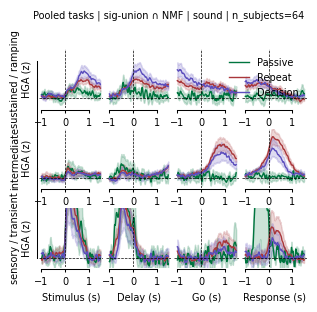

In [8]:
if plot_df.empty:
    print('Nothing to plot — check BIDS / NMF assignment paths.')
else:
    fig = plot_condition_waveforms(
        plot_df,
        save_name='modulation_pooled',
        title=(
            f'Pooled tasks | sig-union ∩ NMF | {MODALITY} | '
            f'n_subjects={plot_df.subject.nunique()}'
        ),
    )


## PictureNaming sustained: why Passive ≈ Repeat?

In **PictureNaming**, both `Passive` and `Repeat` share the same stimulus
stream (here filtered to `sound`). The sustained / ramping cluster often tracks
stimulus-locked / task-general engagement more than the Passive–vs–Repeat
contrast itself, so trial-averaged curves can look nearly aligned.

Also, with **sig-union**, an electrode only significant in one condition still
contributes its (often weak) waveform in the other — that further pulls the two
condition averages together.

Below: replot the pooled figure **excluding PictureNaming sustained / ramping**
(keep intermediate + sensory, and all other tasks). If intermediate also looks
nearly Passive≈Repeat in PN, consider a similar exclusion next.


Excluded rows: 114,240 | remaining subjects: 64 | remaining sustained channels: 98
Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/modulation/modulation_pooled_no_pn_sustained.svg


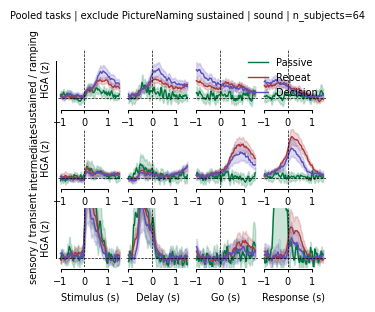

In [9]:
# Drop PictureNaming sustained from the pooled plot
# (keep PN intermediate + sensory, and all other tasks)
drop_mask = (
    (plot_df['task'] == 'PictureNaming')
    & (plot_df['functional_cluster'] == 'sustained_ramping')
)
# plot_df_no_pn_sustained = plot_df.loc[~drop_mask].copy()

plot_df_no_pn_sustained = plot_df.copy()

n_sustained_left = plot_df_no_pn_sustained.loc[
    plot_df_no_pn_sustained.functional_cluster == 'sustained_ramping', 'channel'
].nunique()
print(
    f'Excluded rows: {int(drop_mask.sum()):,} | '
    f'remaining subjects: {plot_df_no_pn_sustained.subject.nunique()} | '
    f'remaining sustained channels: {n_sustained_left}'
)

fig = plot_condition_waveforms(
    plot_df_no_pn_sustained,
    save_name='modulation_pooled_no_pn_sustained',
    title=(
        f'Pooled tasks | exclude PictureNaming sustained | {MODALITY} | '
        f'n_subjects={plot_df_no_pn_sustained.subject.nunique()}'
    ),
)


## Spotlight panels (main claims)

One diagnostic phase per cluster (1×3). Full 3×4 pooled grid above stays as the complete time course.


Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/modulation/modulation_spotlights.svg


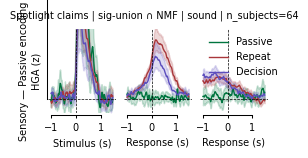

In [10]:
def plot_spotlight_waveforms(
    df: pd.DataFrame,
    spotlights: list[dict],
    *,
    descriptions=DESCRIPTIONS,
    ylim=(-0.1, 0.5),
    title: str | None = None,
    save_name: str | None = None,
):
    """One column per spotlight: single cluster × its diagnostic phase(s)."""
    n_cols = len(spotlights)
    # width scales with number of phase axes inside each spotlight
    widths = [max(len(s["phases"]), 1) for s in spotlights]
    fig, axes = plt.subplots(
        nrows=1,
        ncols=sum(widths),
        figsize=(2.4 * sum(widths) * cm, 2.8 * cm),
        sharey=True,
        squeeze=False,
    )
    plt.subplots_adjust(wspace=0.12, hspace=0.3)
    flat = axes[0]
    col_i = 0
    for spot_i, spec in enumerate(spotlights):
        cluster = spec["cluster"]
        phases = list(spec["phases"])
        claim = spec.get("title", CLUSTER_LABELS.get(cluster, cluster))
        cluster_df = df[df["functional_cluster"] == cluster]
        for j, phase in enumerate(phases):
            ax = flat[col_i]
            phase_df = cluster_df[cluster_df["phase"] == phase]
            present = [d for d in descriptions if (phase_df["description"] == d).any()]
            legend = spot_i == len(spotlights) - 1 and j == len(phases) - 1
            if phase_df.empty or not present:
                ax.text(
                    0.5, 0.5, "n/a", ha="center", va="center",
                    fontsize=fontsize, transform=ax.transAxes, color="0.6",
                )
            else:
                sns.lineplot(
                    data=phase_df,
                    x="time",
                    y="value",
                    hue="description",
                    hue_order=present,
                    ax=ax,
                    palette=[cond_colors[d] for d in present],
                    legend=legend,
                    lw=1,
                    errorbar=("ci", 95),
                )
                if legend and ax.get_legend() is not None:
                    ax.legend(title="", fontsize=fontsize, frameon=False)
                elif ax.get_legend() is not None:
                    ax.get_legend().remove()
            _style_axes(ax, ylim=ylim, hide_left=(col_i != 0))
            ax.set_xlabel(f"{phase.capitalize()} (s)", fontsize=fontsize)
            if j == 0:
                ax.set_ylabel(f"{claim}\nHGA (z)", fontsize=fontsize)
            else:
                ax.set_ylabel("")
            col_i += 1

    if title:
        fig.suptitle(title, fontsize=fontsize, y=1.05)
    if save_name:
        out = IMG_DIR / save_name
        save_svg(fig, out)
        print("Saved", Path(str(out)).with_suffix(".svg"))
    plt.show()
    return fig


SPOTLIGHTS = [
    {
        "cluster": "sensory_transient",
        "phases": ["stimulus"],
        "title": "Sensory — Passive encoding",
    },
    {
        "cluster": "intermediate",
        "phases": ["response"],
        "title": "Intermediate — Repeat > Decision",
    },
    {
        "cluster": "sustained_ramping",
        "phases": ["response"],
        "title": "Sustained — Decision >> Repeat",
    },
]

if plot_df.empty:
    print("Nothing to plot — check BIDS / NMF assignment paths.")
else:
    fig = plot_spotlight_waveforms(
        plot_df,
        SPOTLIGHTS,
        save_name="modulation_spotlights",
        title=(
            f"Spotlight claims | sig-union ∩ NMF | {MODALITY} | "
            f"n_subjects={plot_df.subject.nunique()}"
        ),
    )


## Per-task panels

Same layout, one figure per task (only conditions present in that task).


LexicalDelay: conditions=['Repeat', 'Decision'] | channels=170 | subjects=40
Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/modulation/modulation_LexicalDelay.svg


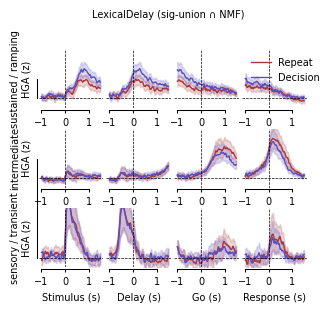

LexicalNoDelay: conditions=['Passive', 'Repeat', 'Decision'] | channels=50 | subjects=15
Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/modulation/modulation_LexicalNoDelay.svg


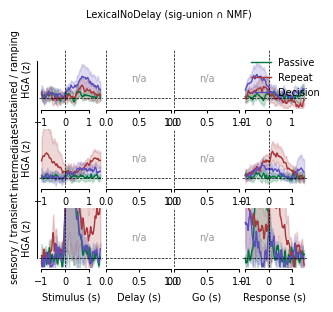

PhonemeSequence: conditions=['Repeat'] | channels=114 | subjects=33
Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/modulation/modulation_PhonemeSequence.svg


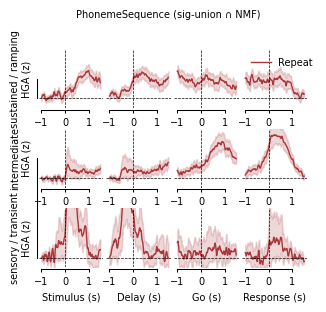

PictureNaming: conditions=['Passive', 'Repeat'] | channels=121 | subjects=28
Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/modulation/modulation_PictureNaming.svg


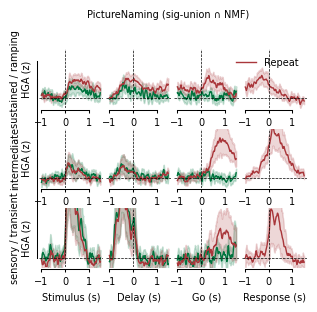

In [11]:
for task in TASKS:
    task_df = plot_df[plot_df['task'] == task] if len(plot_df) else pd.DataFrame()
    if task_df.empty:
        print(f'{task}: no rows — skip')
        continue
    _order = {d: i for i, d in enumerate(DESCRIPTIONS)}
    present = sorted(task_df['description'].unique(), key=lambda d: _order.get(d, 99))
    print(
        f'{task}: conditions={present} | '
        f'channels={task_df.channel.nunique()} | subjects={task_df.subject.nunique()}'
    )
    plot_condition_waveforms(
        task_df,
        descriptions=[d for d in DESCRIPTIONS if d in present],
        title=f'{task} (sig-union ∩ NMF)',
        save_name=f'modulation_{task}',
    )


## Spatial: Decision > Repeat (phase union)

Temporal panels above use trial-averaged HGA. This section adds the **spatial**
summary for `LexicalDelay` window-mean `DecisionVsRepeatMean`:

- Electrodes significant for **Decision larger** in any phase (union)
- Color = NMF k=3 cluster (red=sustained, gold=intermediate, blue=sensory)
- Size = `|mean_diff|` (Decision−Repeat)

Reads Mean CSVs via `resolve_mean_results_root` (sibling `insula/results` when
needed) and the canonical `results/nmf/channel_assignments.csv`.

Output: `img/modulation/LexicalDelay_DecisionVsRepeat_Decision_union_cluster_brain_k3.svg`.


2026-07-28 10:36:50 - INFO - Loaded NMF k=3 assignments from /hpc/group/coganlab/nanlinshi/insula-functional/results/nmf/channel_assignments.csv (281 channels)
2026-07-28 10:36:50 - INFO - DecisionVsRepeat cluster table (k=3): 122 significant assigned rows (73 Decision, 49 Repeat) from /hpc/group/coganlab/nanlinshi/insula/results
results_root=/hpc/group/coganlab/nanlinshi/insula/results | rows=122
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-28 10:36:50.922 ( 271.823s) [    7F796760D740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1630f370): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

2026-07-28 10:36:53 - INFO - Saved /hpc/group/coganlab/nanlinshi/insula-functional/img/modulation/LexicalDelay_DecisionVsRepeat_Repeat_union_cluster_brain_k3.svg
/hpc/group/coganlab/nanlinshi/insula-functional/img/modulation/LexicalDelay_DecisionVsRepeat_Repeat_union_cluster_brain_k3.svg


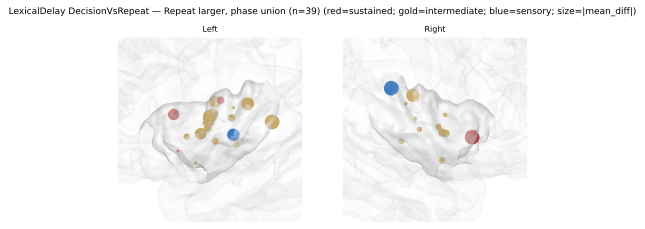

In [13]:
from IPython.display import SVG, display

from src.univariate.viz_cluster_direction import (
    load_decision_vs_repeat_table,
    plot_direction_union_brain,
)
from src.univariate.viz_mean import BrainSurfaceContext

table, root = load_decision_vs_repeat_table(k=3)
print(f'results_root={root} | rows={len(table)}')

path = plot_direction_union_brain(
    table,
    IMG_DIR,
    direction='Repeat',
    k=3,
    ctx=BrainSurfaceContext(),
    size_by_effect=True,
)
print(path)
display(SVG(filename=str(path)))
